### Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import os
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR

import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms

from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


### Установка seed для воспроизводимости

In [2]:
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(42)

### Проверка GPU

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Training on CPU...")

Training on GPU: Tesla T4


### Конфигурация

In [4]:
CONFIG = {
    'img_size': 224,
    'batch_size': 64,
    'num_classes': 4,
    'epochs': 11,
    'lr_max': 1e-3,
    'lr_min': 1e-6,
    'weight_decay': 1e-4,
    'label_smoothing': 0.1,
    'mixup_alpha': 0.2,
    'dropout': 0.3,
    'val_split': 0.2,
    'seed': 42,
    'num_workers': 4,
    'tta_steps': 5,  # Количество аугментаций для TTA
}

# пути к данным
TRAIN_VAL_PATH = "/kaggle/input/optical-coherence-tomography-classification/Dataset"
TEST_PATH = "/kaggle/input/optical-coherence-tomography-classification/Test"
OUTPUT_DIR = "/kaggle/working/"


### Аугментации

In [5]:
# Трансформации для обучения (с аугментациями)
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),  # OCT могут быть в любой ориентации
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Трансформации для валидации и теста (без аугментаций)
val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Трансформации для TTA
tta_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


### Загрузка датасета и анализ распределения классов

In [6]:
full_dataset = ImageFolder(TRAIN_VAL_PATH)
class_names = full_dataset.classes
print(f"Классы: {class_names}")
print(f"Всего изображений: {len(full_dataset)}")

# количество примеров каждого класса
targets = [full_dataset.targets[i] for i in range(len(full_dataset))]
class_counts = Counter(targets)
print(f"\nРаспределение классов:")
for idx, count in sorted(class_counts.items()):
    print(f"   {class_names[idx]} ({idx}): {count}")

Классы: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Всего изображений: 108309

Распределение классов:
   CNV (0): 37205
   DME (1): 11348
   DRUSEN (2): 8616
   NORMAL (3): 51140


### Создание WeightedRandomSampler для балансировки классов

In [7]:
def create_weighted_sampler(dataset, indices=None):
    """
    Создает WeightedRandomSampler для балансировки классов.
    Каждому примеру присваивается вес, обратный частоте его класса.
    """
    if indices is not None:
        targets = [dataset.targets[i] for i in indices]
    else:
        targets = dataset.targets
    
    class_counts = Counter(targets)
    num_classes = len(class_counts)
    
    # Вес для каждого класса 
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    
    # Вес для каждого примера
    sample_weights = [class_weights[t] for t in targets]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    return sampler

### Разбиение на train/val

In [8]:
def split_train_val(dataset, val_percentage=0.2, seed=42):
    """
    Разделяет датасет на train и validation с сохранением пропорций классов.
    """
    np.random.seed(seed)
    total_len = len(dataset)
    indices = np.random.permutation(total_len)
    
    val_len = int(total_len * val_percentage)
    val_indices = indices[:val_len]
    train_indices = indices[val_len:]
    
    return train_indices, val_indices

train_indices, val_indices = split_train_val(
    full_dataset, 
    val_percentage=CONFIG['val_split'],
    seed=CONFIG['seed']
)

print(f"Train: {len(train_indices)} примеров")
print(f"Val: {len(val_indices)} примеров")

Train: 86648 примеров
Val: 21661 примеров


In [9]:
# Создаем датасеты с нужными трансформациями
train_dataset_base = ImageFolder(TRAIN_VAL_PATH, transform=train_transform)
val_dataset_base = ImageFolder(TRAIN_VAL_PATH, transform=val_transform)

# Создаем Subset
train_dataset = Subset(train_dataset_base, train_indices)
val_dataset = Subset(val_dataset_base, val_indices)

# Создаем sampler
train_sampler = create_weighted_sampler(train_dataset_base, train_indices)

### DataLoaders

In [10]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    sampler=train_sampler,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

# без балансировки
val_dataloader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

### Focal Loss для работы с дисбалансом классов

In [11]:
class FocalLoss(nn.Module):
    """
    Focal Loss для работы с несбалансированными классами.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    
    Параметры:
    - alpha: вес для каждого класса (для балансировки)
    - gamma: фокусирующий параметр (чем больше, тем меньше внимание к легким примерам)
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # вероятность правильного класса
        
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            if isinstance(self.alpha, (list, tuple, np.ndarray)):
                alpha = torch.tensor(self.alpha, device=inputs.device)
            else:
                alpha = self.alpha
            alpha_t = alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Вычисляем веса классов для Focal Loss
class_counts_list = [class_counts[i] for i in range(len(class_names))]
total_samples = sum(class_counts_list)
class_weights = [total_samples / (len(class_names) * count) for count in class_counts_list]

print(f"Веса классов для Focal Loss:")
for i, (name, weight) in enumerate(zip(class_names, class_weights)):
    print(f"   {name} ({i}): {weight:.3f}")

criterion = FocalLoss(alpha=class_weights, gamma=2.0)
criterion = criterion.to(device)


Веса классов для Focal Loss:
   CNV (0): 0.728
   DME (1): 2.386
   DRUSEN (2): 3.143
   NORMAL (3): 0.529


### Mixup для улучшения генерализации

In [12]:
def mixup_data(x, y, alpha=0.2):
    """
    Применяет Mixup к батчу данных.
    Смешивает пары примеров и их метки.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """
    Вычисляет loss для смешанных данных.
    """
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


### Создание модели EfficientNet-B0

In [13]:
def create_efficientnet(num_classes, pretrained=True, dropout=0.3):
    """
    Создает модель EfficientNet-B0 с модифицированным классификатором.
    """
    if pretrained:
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        model = efficientnet_b0(weights=weights)
    else:
        model = efficientnet_b0(weights=None)
    
    # количество входных признаков классификатора
    in_features = model.classifier[1].in_features
    
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    
    return model

model = create_efficientnet(
    num_classes=CONFIG['num_classes'],
    pretrained=True,
    dropout=CONFIG['dropout']
)

model = model.to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s]


### Оптимизатор и Scheduler

In [14]:
# Оптимизатор с weight decay
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr_max'],
    weight_decay=CONFIG['weight_decay']
)

# Cosine Annealing с warm restarts
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,  # Период первого рестарта (в эпохах)
    T_mult=2,  # Множитель для увеличения периода
    eta_min=CONFIG['lr_min']
)

### Функции обучения

In [15]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, use_mixup=True, mixup_alpha=0.2):
    """
    Обучение одной эпохи.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        if use_mixup and random.random() < 0.5:  # Применяем mixup с вероятностью 50%
            images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        loss.backward()
        
        # Gradient clipping для стабильности
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """
    Валидация модели.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels



### Основной цикл обучения

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                device, epochs, use_mixup=True):
    """
    Полный цикл обучения с сохранением лучшей модели.
    """
    best_val_acc = 0.0
    best_val_loss = float('inf')
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        
        # Обучение
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            use_mixup=use_mixup, mixup_alpha=CONFIG['mixup_alpha']
        )
        
        # Валидация
        val_loss, val_acc, val_preds, val_labels = validate(
            model, val_loader, criterion, device
        )
        
        # Обновление scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Вывод статистики
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        print(f"LR: {current_lr:.6f}")
        
        # Сохранение лучшей модели
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            }
            torch.save(checkpoint, os.path.join(OUTPUT_DIR, 'best_model.pth'))
            print(f"Лучшая модель сохранена! Acc: {val_acc:.4f}")
        
        # Раннее остановка при достижении целевой точности
        if val_acc >= 0.97:
            print(f"\nДостигнута целевая точность: {val_acc:.4f}")
            break
    
    print(f"Обучение завершено!")
    print(f"Лучшая Val Acc: {best_val_acc:.4f}")
    print(f"Лучшая Val Loss: {best_val_loss:.4f}")
    
    return history

### Запуск обучения

In [17]:
%%time

history = train_model(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=CONFIG['epochs'],
    use_mixup=True
)

Epoch 1/11
Train Loss: 0.2571 | Train Acc: 0.7287
Val Loss: 0.0733 | Val Acc: 0.9291
LR: 0.000905
Лучшая модель сохранена! Acc: 0.9291
Epoch 2/11
Train Loss: 0.1886 | Train Acc: 0.7440
Val Loss: 0.0791 | Val Acc: 0.9219
LR: 0.000655
Epoch 3/11
Train Loss: 0.1558 | Train Acc: 0.7652
Val Loss: 0.0684 | Val Acc: 0.9231
LR: 0.000346
Epoch 4/11
Train Loss: 0.1371 | Train Acc: 0.7677
Val Loss: 0.0379 | Val Acc: 0.9617
LR: 0.000096
Лучшая модель сохранена! Acc: 0.9617
Epoch 5/11
Train Loss: 0.1231 | Train Acc: 0.7682
Val Loss: 0.0387 | Val Acc: 0.9536
LR: 0.001000
Epoch 6/11
Train Loss: 0.1580 | Train Acc: 0.7456
Val Loss: 0.0464 | Val Acc: 0.9552
LR: 0.000976
Epoch 7/11
Train Loss: 0.1522 | Train Acc: 0.7648
Val Loss: 0.0459 | Val Acc: 0.9441
LR: 0.000905
Epoch 8/11
Train Loss: 0.1430 | Train Acc: 0.7554
Val Loss: 0.0526 | Val Acc: 0.9343
LR: 0.000794
Epoch 9/11
Train Loss: 0.1351 | Train Acc: 0.7611
Val Loss: 0.0407 | Val Acc: 0.9490
LR: 0.000655
Epoch 10/11
Train Loss: 0.1238 | Train Acc: 

### Визуализация процесса обучения

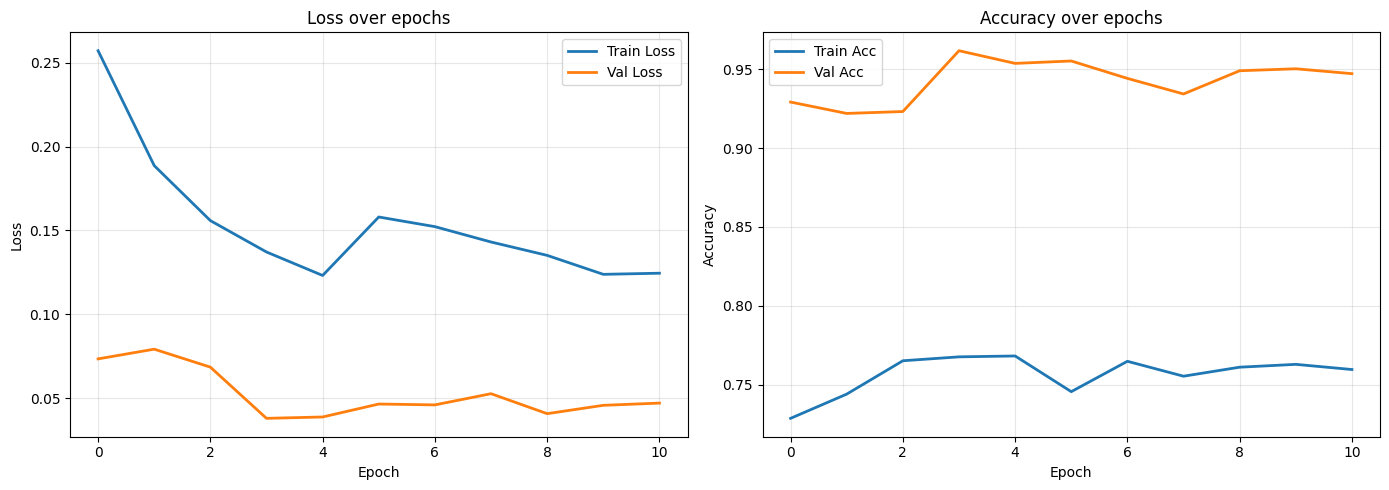

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150)
plt.show()

### Confusion Matrix на валидации

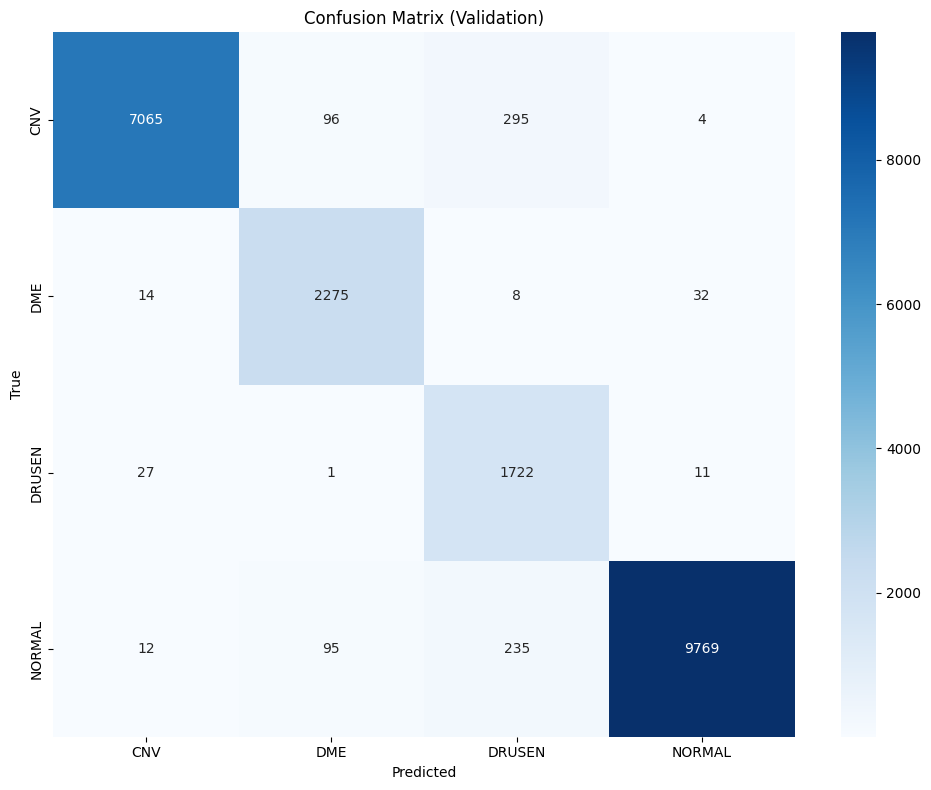


Classification Report:
              precision    recall  f1-score   support

         CNV       0.99      0.95      0.97      7460
         DME       0.92      0.98      0.95      2329
      DRUSEN       0.76      0.98      0.86      1761
      NORMAL       1.00      0.97      0.98     10111

    accuracy                           0.96     21661
   macro avg       0.92      0.97      0.94     21661
weighted avg       0.97      0.96      0.96     21661



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Загружаем лучшую модель
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'), map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Получаем предсказания
_, _, val_preds, val_labels = validate(model, val_dataloader, criterion, device)

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=class_names))

### Класс TestDataset

In [20]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.filenames = sorted(os.listdir(root_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.filenames[idx])
        image = Image.open(img_name)
        image = image.convert('RGB')
        
        if self.transform:
            image = self.transform(image)

        return image

test_dataset = TestDataset(TEST_PATH, val_transform)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers']
)

print(f"Test dataset: {len(test_dataset)} изображений")

Test dataset: 1000 изображений


### TTA (Test Time Augmentation)

In [21]:
def predict_with_tta(model, dataset, device, tta_steps=5):
    """
    Предсказание с Test Time Augmentation.
    Усредняет предсказания по нескольким аугментированным версиям каждого изображения.
    """
    model.eval()
    
    all_probs = []
    
    for tta_idx in range(tta_steps):
        print(f"TTA step {tta_idx + 1}/{tta_steps}")
        
        # Создаем датасет с разными аугментациями
        if tta_idx == 0:
            # Первый проход без аугментаций
            tta_dataset = TestDataset(TEST_PATH, val_transform)
        else:
            # Последующие проходы с аугментациями
            tta_dataset = TestDataset(TEST_PATH, tta_transform)
        
        tta_loader = DataLoader(
            tta_dataset,
            batch_size=CONFIG['batch_size'],
            shuffle=False,
            num_workers=CONFIG['num_workers']
        )
        
        batch_probs = []
        with torch.no_grad():
            for images in tta_loader:
                images = images.to(device)
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                batch_probs.append(probs.cpu())
        
        all_probs.append(torch.cat(batch_probs, dim=0))
    
    # Усредняем вероятности по всем TTA проходам
    avg_probs = torch.stack(all_probs).mean(dim=0)
    _, predictions = avg_probs.max(dim=1)
    
    return predictions.numpy(), avg_probs.numpy()

print("Функция predict_with_tta определена")

Функция predict_with_tta определена


### Предсказание на тесте

In [22]:
print(f"Предсказание на тесте с TTA ({CONFIG['tta_steps']} шагов)...")

predictions, probs = predict_with_tta(
    model,
    test_dataset,
    device,
    tta_steps=CONFIG['tta_steps']
)

print(f"\nПредсказания получены: {len(predictions)} изображений")

Предсказание на тесте с TTA (5 шагов)...
TTA step 1/5
TTA step 2/5
TTA step 3/5
TTA step 4/5
TTA step 5/5

Предсказания получены: 1000 изображений


### Формирование submission

In [23]:
submission = pd.DataFrame({
    'ImageId': range(1, len(predictions) + 1),
    'Label': predictions
})

print(submission.head(10))
print(f"\nРаспределение предсказаний:")
print(submission['Label'].value_counts().sort_index())

# Сохранение
submission.to_csv(os.path.join(OUTPUT_DIR, 'submission.csv'), index=False)
print(f"\nsubmission.csv сохранен")

   ImageId  Label
0        1      1
1        2      2
2        3      0
3        4      2
4        5      0
5        6      1
6        7      2
7        8      2
8        9      0
9       10      1

Распределение предсказаний:
Label
0    262
1    251
2    252
3    235
Name: count, dtype: int64

submission.csv сохранен
